# Assignment - 2

## Spectral Clustering

Perform spectral clustering
Note:
1. Identify number of clusters in the graph
2. Print cluster number for each node

Submitted by -

1.   Akarsh Dubey CS25MTECH14001
2.   Atish Kadam   CS25MTECH14003



**Importing required library**

In [ ]:
#!pip install networkx scikit-learn matplotlib pandas numpy
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

**Loading dataset by removing existing files from /contents**

In [ ]:
!rm -rf /content/*
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("/content/spectral_graph_600nodes_edges - spectral_graph_600nodes_edges.csv")
print(f"Loaded {len(df):,}")

Saving spectral_graph_600nodes_edges - spectral_graph_600nodes_edges.csv to spectral_graph_600nodes_edges - spectral_graph_600nodes_edges.csv
Loaded 6,734


**Building Graph - We are using undirected graph**

In [ ]:
# Read column names from the CSV instead of hard-coding them
col_src, col_tgt = df.columns[0], df.columns[1]

G = nx.from_pandas_edgelist(df, source=col_src, target=col_tgt)
N = G.number_of_nodes()          # dynamic – works for any graph
print(f"\nGraph  →  Nodes: {N}  |  Edges: {G.number_of_edges()}")


Graph  →  Nodes: 600  |  Edges: 6734


**Computing Laplacian Matrix**

In [ ]:
L_norm = nx.normalized_laplacian_matrix(G).toarray()
print("\nNormalized Laplacian computed  →  shape:", L_norm.shape)


Normalized Laplacian computed  →  shape: (600, 600)


**Eigen Decomposition**

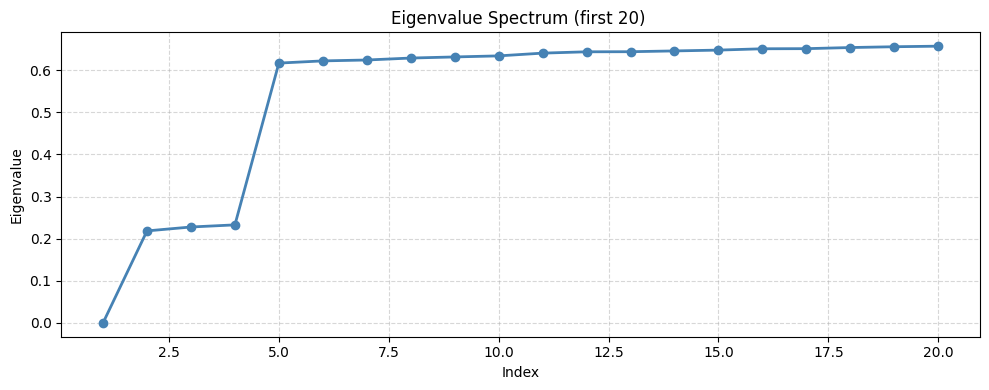

In [ ]:
eigenvalues, eigenvectors = np.linalg.eigh(L_norm)

# Plot first 20 eigenvalues to visualise the spectrum
PLOT_K = min(20, N)
plt.figure(figsize=(10, 4))
plt.plot(range(1, PLOT_K + 1), eigenvalues[:PLOT_K], "o-",
         color="steelblue", linewidth=2)
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalue Spectrum (first 20) ")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Identify No. of Cluster - k**

In [ ]:
# Stage 1: connected-components
n_components = nx.number_connected_components(G)

if n_components >= 2:
    # Disconnected graph — k is exact, eigengap not needed
    k = int(n_components)
    use_kmeans = False
    # Build node → component-index mapping
    comp_map = {}
    for idx, component in enumerate(nx.connected_components(G)):
        for node in component:
            comp_map[node] = idx
    nodes = list(G.nodes())
    labels = np.array([comp_map[n] for n in nodes])
    print(f"Graph has {n_components} disconnected components.")
    print(f"k = {k}  (exact — from connected-components, no heuristic needed)")

else:
    #  Stage 2: eigengap heuristic
    use_kmeans = True
    print("Graph is fully connected — using eigengap heuristic.\n")

    # K_MAX scales with graph size instead of being hard-coded
    K_MAX = min(50, N // 10)

    gaps  = np.diff(eigenvalues[1:K_MAX + 1])   # skip trivial λ_1 ≈ 0
    k     = int(np.argmax(gaps)) + 2
    print(f"Search window  K_MAX = {K_MAX}")
    print(f"Spectral gap analysis  →  suggested number of clusters  k = {k}")

Graph is fully connected — using eigengap heuristic.

Search window  K_MAX = 50
Spectral gap analysis  →  suggested number of clusters  k = 4


**Building Spectral Embedding**

In [ ]:
if use_kmeans:
    embedding = eigenvectors[:, 1:k+1]                  # shape: (N, k)
    embedding_norm = normalize(embedding, norm="l2")      # row-wise L2
    print(f"Spectral embedding shape: {embedding_norm.shape}  (nodes × k)")
else:
    print(f"Embedding step skipped — labels already assigned from connected components.")

Spectral embedding shape: (600, 4)  (nodes × k)


**K-MEANS clustering in embeddings**

In [ ]:
if use_kmeans:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = kmeans.fit_predict(embedding_norm)   # cluster label per node
    print(f"K-Means complete  →  k = {k} clusters")
else:
    print(f"K-Means skipped — using connected-component labels directly.")

K-Means complete  →  k = 4 clusters


**Printing Cluster assignment for each and every node**

In [ ]:
nodes = list(G.nodes())
print(f"\n{'Node':>6}  {'Cluster':>7}")
print("-" * 16)
for node, label in zip(nodes, labels):
    print(f"{node:>6}  {label:>7}")

# Summary table
result_df = pd.DataFrame({"Node": nodes, "Cluster": labels}).sort_values("Node")
print("\nCluster size distribution:")
print(result_df["Cluster"].value_counts().sort_index().to_string())
print("Number of connected components:", n_components)


  Node  Cluster
----------------
     0        2
     1        2
     2        2
     4        2
     6        2
    14        2
    16        2
    18        2
    22        2
    25        2
    48        2
    57        2
    62        2
    64        2
    80        2
    88        2
    89        2
    91        2
    93        2
    95        2
   112        2
   114        2
   128        2
   138        2
   340        1
   512        3
    13        2
    39        2
    51        2
    66        2
    81        2
    85        2
   102        2
   110        2
   119        2
   125        2
   129        2
   140        2
   142        2
   145        2
   410        1
   517        3
   587        3
   466        3
     5        2
     9        2
    20        2
    28        2
    33        2
    38        2
    45        2
    47        2
    53        2
    56        2
    65        2
    71        2
    72        2
    92        2
    96        2
   100        2
   105

**Eigengap bar chart and Eigenvalues of Normalized Laplacian**

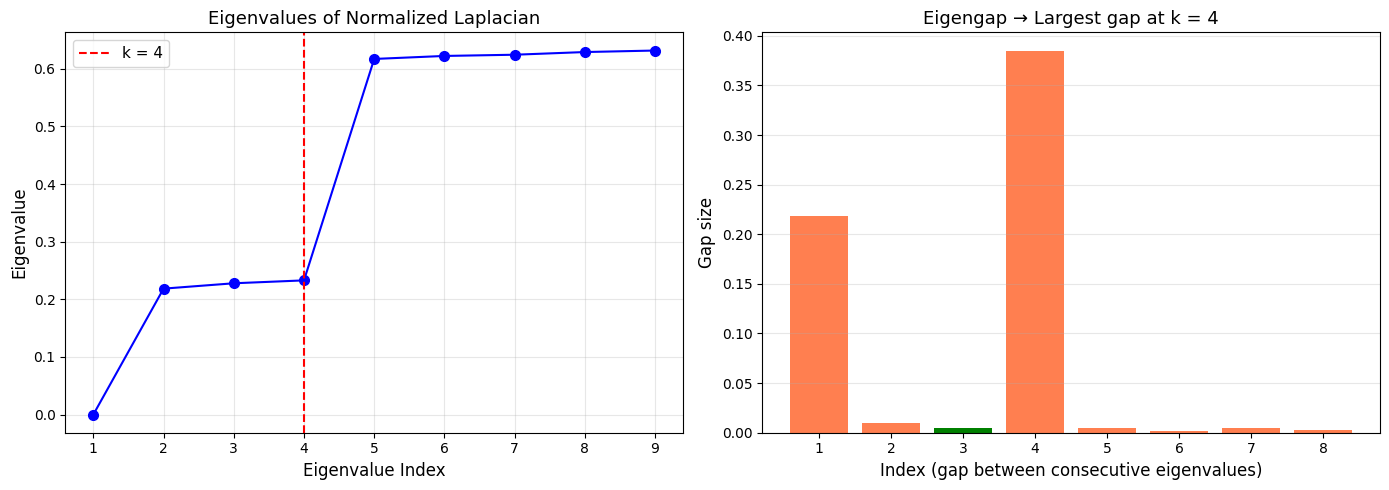

In [ ]:
n_colors = max(k, 10)
cmap     = matplotlib.colormaps.get_cmap("tab20").resampled(n_colors)

fig0, axes0 = plt.subplots(1, 2, figsize=(14, 5))

PLOT_K = min(k, N) + 5
axes0[0].plot(range(1, PLOT_K + 1), eigenvalues[:PLOT_K], "bo-", markersize=7)
axes0[0].axvline(x=k, color="red", linestyle="--", linewidth=1.5, label=f"k = {k}")
axes0[0].set_xlabel("Eigenvalue Index", fontsize=12)
axes0[0].set_ylabel("Eigenvalue", fontsize=12)
axes0[0].set_title("Eigenvalues of Normalized Laplacian", fontsize=13)
axes0[0].legend(fontsize=11)
axes0[0].grid(True, alpha=0.3)

all_gaps  = np.diff(eigenvalues[:PLOT_K])
gap_x     = range(1, len(all_gaps) + 1)
bar_colors = ["green" if (i + 2) == k else "coral" for i in range(len(all_gaps))]
axes0[1].bar(gap_x, all_gaps, color=bar_colors)
axes0[1].set_xlabel("Index (gap between consecutive eigenvalues)", fontsize=12)
axes0[1].set_ylabel("Gap size", fontsize=12)
axes0[1].set_title(f"Eigengap → Largest gap at k = {k}", fontsize=13)
axes0[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("eigengap_chart.png", dpi=150, bbox_inches="tight")
plt.show()

**Graph visualisation of all clusters**


Generating graph visualisation 


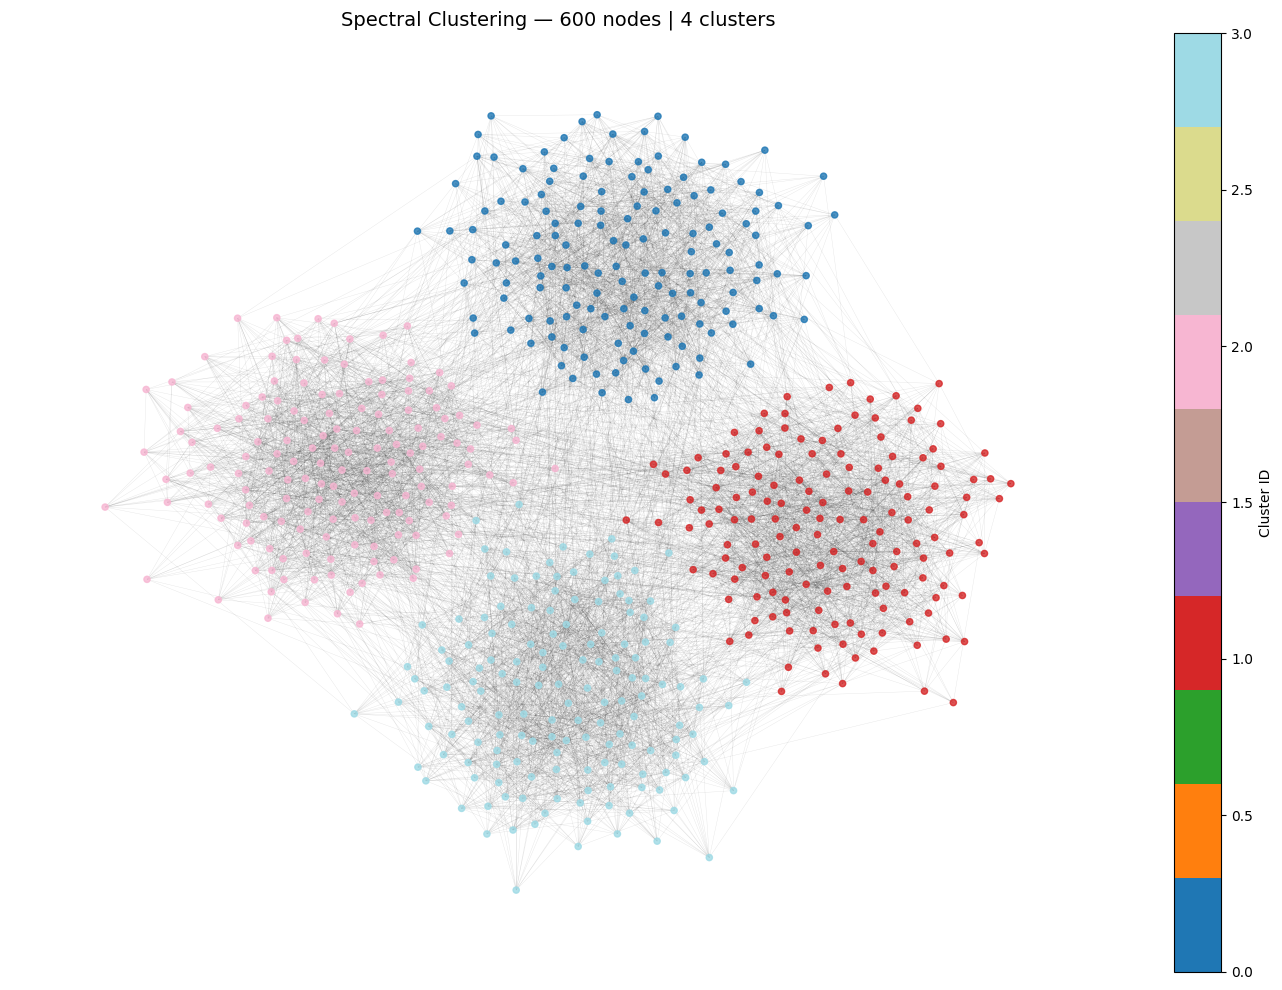

In [ ]:
print("\nGenerating graph visualisation ")
node_list   = list(G.nodes())
node_to_pos = {n: i for i, n in enumerate(node_list)}
# ALWAYS use full graph
H = G
sub_labels = labels  # labels already aligned with node_list
fig2, ax2 = plt.subplots(figsize=(14, 10))
# Adjust layout for large graphs
pos = nx.spring_layout(H, seed=42, k=0.15)  # smaller k → tighter layout
nx.draw_networkx_nodes(
    H, pos,
    node_color=[int(sub_labels[node_to_pos[n]]) for n in H.nodes()],
    cmap=cmap,
    node_size=20,        # reduce size for visibility
    alpha=0.8,
    ax=ax2
)

nx.draw_networkx_edges(
    H, pos,
    alpha=0.1,
    width=0.3,
    ax=ax2
)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=k - 1))
sm.set_array([])
fig2.colorbar(sm, ax=ax2, label="Cluster ID")

ax2.set_title(f"Spectral Clustering — {N} nodes | {k} clusters", fontsize=14)
ax2.axis("off")

plt.tight_layout()
plt.show()

**Final Summary table**

In [ ]:
if use_kmeans:
    # In case you called K-Means earlier, make sure cluster_labels exists
    try:
        cluster_arr = labels
    except NameError:
        # fallback if variable missing
        cluster_arr = np.zeros(N, dtype=int)
else:
    cluster_arr = labels  # already defined for disconnected graph

nodes_list = list(G.nodes())

print("-" * 60)
print("  FINAL SUMMARY")
print("-" * 60)

print(f"  Graph             : {N} nodes, {G.number_of_edges()} edges")
print(f"  Connected comps   : {n_components}")
print(f"  Graph type        : {'Connected' if use_kmeans else 'Disconnected'}\n")

print(f"  Method            : Spectral Clustering")
print(f"  Laplacian         : Normalized (I - D^(-1/2) A D^(-1/2))")
print(f"  k identified      : {k}")
print(f"  k method          : {'Eigengap heuristic' if use_kmeans else 'Connected components (exact)'}")
print(f"  Final clustering  : {'K-Means on spectral embedding' if use_kmeans else 'Component membership'}\n")
print("-" * 60)
print(f"      Cluster breakdown :")
for c in range(k):
    count        = (labels == c).sum()
    node_preview = list(result_df[result_df["Cluster"] == c]["Node"].values[:5])
    print(f"    Cluster {c:3d} : {count:4d} nodes  ")
print("-" * 60)

------------------------------------------------------------
  FINAL SUMMARY
------------------------------------------------------------
  Graph             : 600 nodes, 6734 edges
  Connected comps   : 1
  Graph type        : Connected

  Method            : Spectral Clustering
  Laplacian         : Normalized (I - D^(-1/2) A D^(-1/2))
  k identified      : 4
  k method          : Eigengap heuristic
  Final clustering  : K-Means on spectral embedding

------------------------------------------------------------
      Cluster breakdown :
    Cluster   0 :  150 nodes  
    Cluster   1 :  150 nodes  
    Cluster   2 :  150 nodes  
    Cluster   3 :  150 nodes  
------------------------------------------------------------
